In [242]:
import pandas as pd
import matplotlib
from matplotlib import pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns
sns.set()
import numpy as np

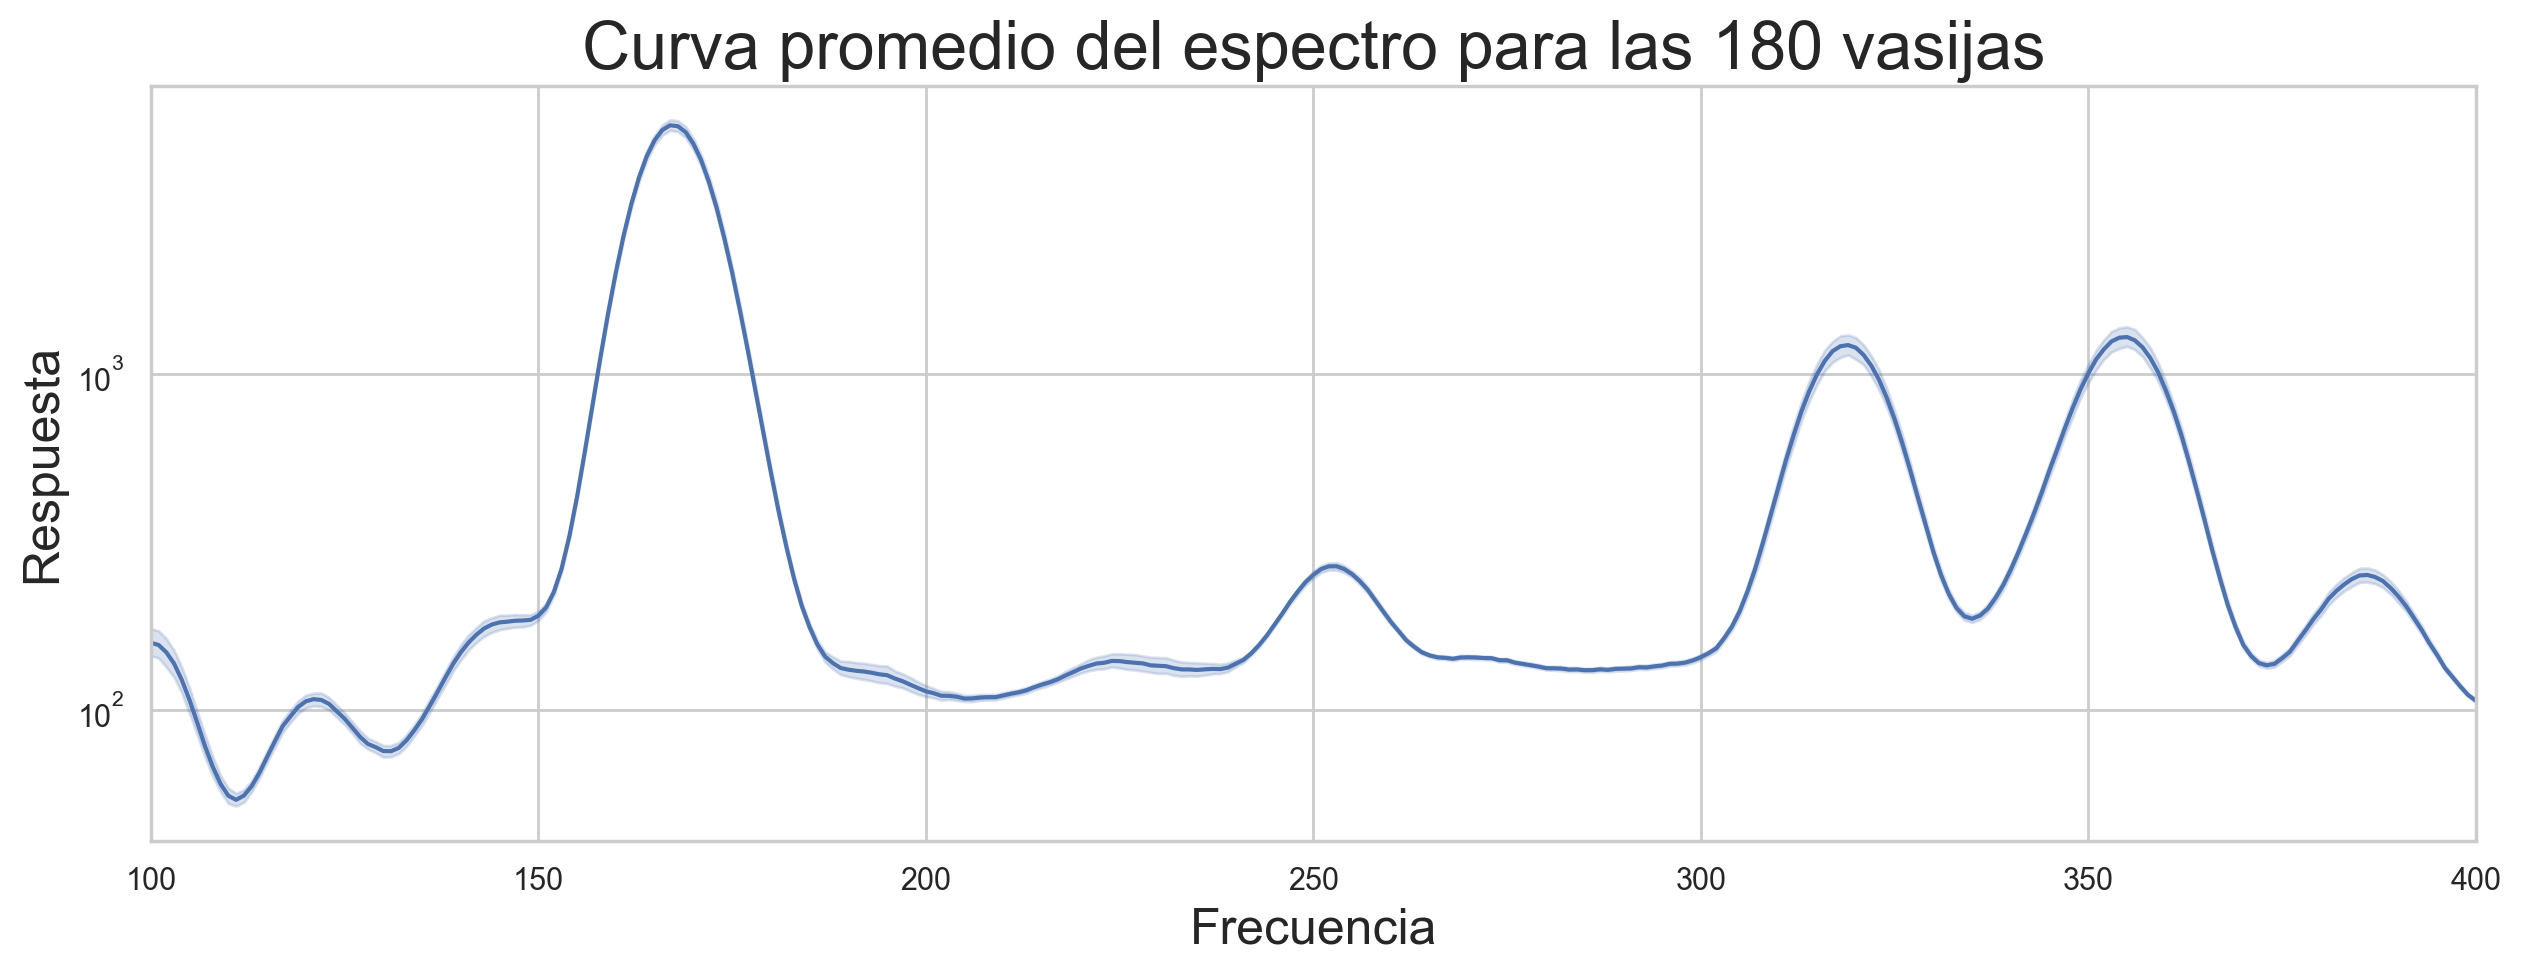

In [255]:
df = pd.read_csv("Vessel_X.txt", header=None)
df.columns = range(100, 401)

a = df.stack().to_frame().reset_index()[['level_1', 0]]
a.columns = ["frecuencia", "respuesta"]

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(nrows=1, ncols=1, dpi=200, figsize=(15, 5))
plt.title("Curva promedio del espectro para las 180 vasijas", fontsize=24)

sns.lineplot(x="frecuencia", y="respuesta", data=a, ax=ax).set(yscale='log')
ax.set_xlim(100, 400)

ax.set_xlabel("Frecuencia", fontsize=18)
ax.set_ylabel("Respuesta", fontsize=18)
plt.show()

In [ ]:
df = pd.read_csv("Vessel_X.txt", header=None)
df.columns = [("f" + str(x)) for x in range(100, 401)]
Y = pd.read_csv("Vessel_Y.txt", header=None)
dfY = df.copy()
dfY['Y'] = Y.loc[:,0]

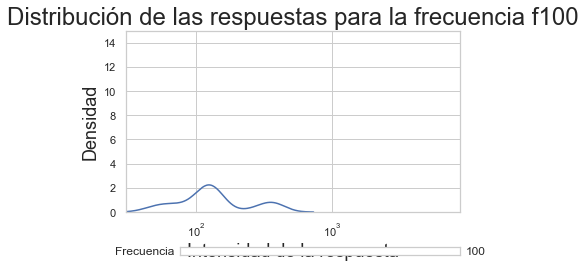

In [284]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button

sns.set_theme(style="whitegrid")

df = pd.read_csv("Vessel_X.txt", header=None)
df.columns = [("f" + str(x)) for x in range(100, 401)]


fig, ax = plt.subplots()
plt.subplots_adjust(bottom=0.25)

def update(val):
    ax.clear()
    ax.set_xlim(df.min().min(), df.max().max())
    ax.set_ylim(0, 15)
    ax.set_xlabel("Intensidad de la respuesta", fontsize=18)
    ax.set_ylabel("Densidad", fontsize=18)
    freq = 'f' + str(int(val))
    ax.set_title("Distribución de las respuestas para la frecuencia " + freq, fontsize=24)
    sns.kdeplot(np.array(df[freq]), ax=ax, log_scale=True)

axfreq = plt.axes([0.25, 0.1, 0.65, 0.03])

freq_slider = Slider(
    ax=axfreq,
    label='Frecuencia',
    valmin=100,
    valmax=400,
    valinit=100,
    valfmt='%0.0f',
)
freq_slider.on_changed(update)

update(freq_slider.valinit)
plt.show()

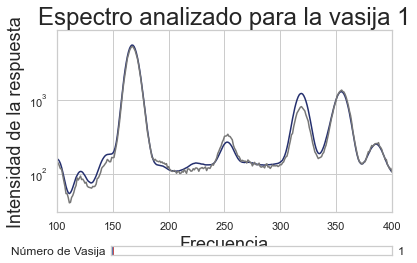

In [295]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button


sns.set_theme(style="whitegrid")

df = pd.read_csv("Vessel_X.txt", header=None)
df.columns = [("f" + str(x)) for x in range(100, 401)]

fig, ax = plt.subplots()
plt.subplots_adjust(bottom=0.25)

def update(val):
    ax.clear()
    ax.set_xlim(100, 400)
    ax.set_ylim(df.min().min(), df.max().max())
    
    ax.set_xlabel("Frecuencia", fontsize=18)
    ax.set_ylabel("Intensidad de la respuesta", fontsize=18)
    ax.set_title("Espectro analizado para la vasija " + str(int(val)), fontsize=24)

    sns.lineplot(x=range(100, 401), y=df.mean(), ax=ax, color='#242F6E')
    sns.lineplot(x=range(100, 401), y=df.loc[int(val)], ax=ax, color='#777777')

axvasj = plt.axes([0.25, 0.1, 0.65, 0.03])

freq_slider = Slider(
    ax=axvasj,
    label='Número de Vasija',
    valmin=0,
    valmax=179,
    valinit=1,
    valfmt='%0.0f',
)

freq_slider.on_changed(update)

update(freq_slider.valinit)
plt.show()

In [132]:
import matplotlib.colors


[]

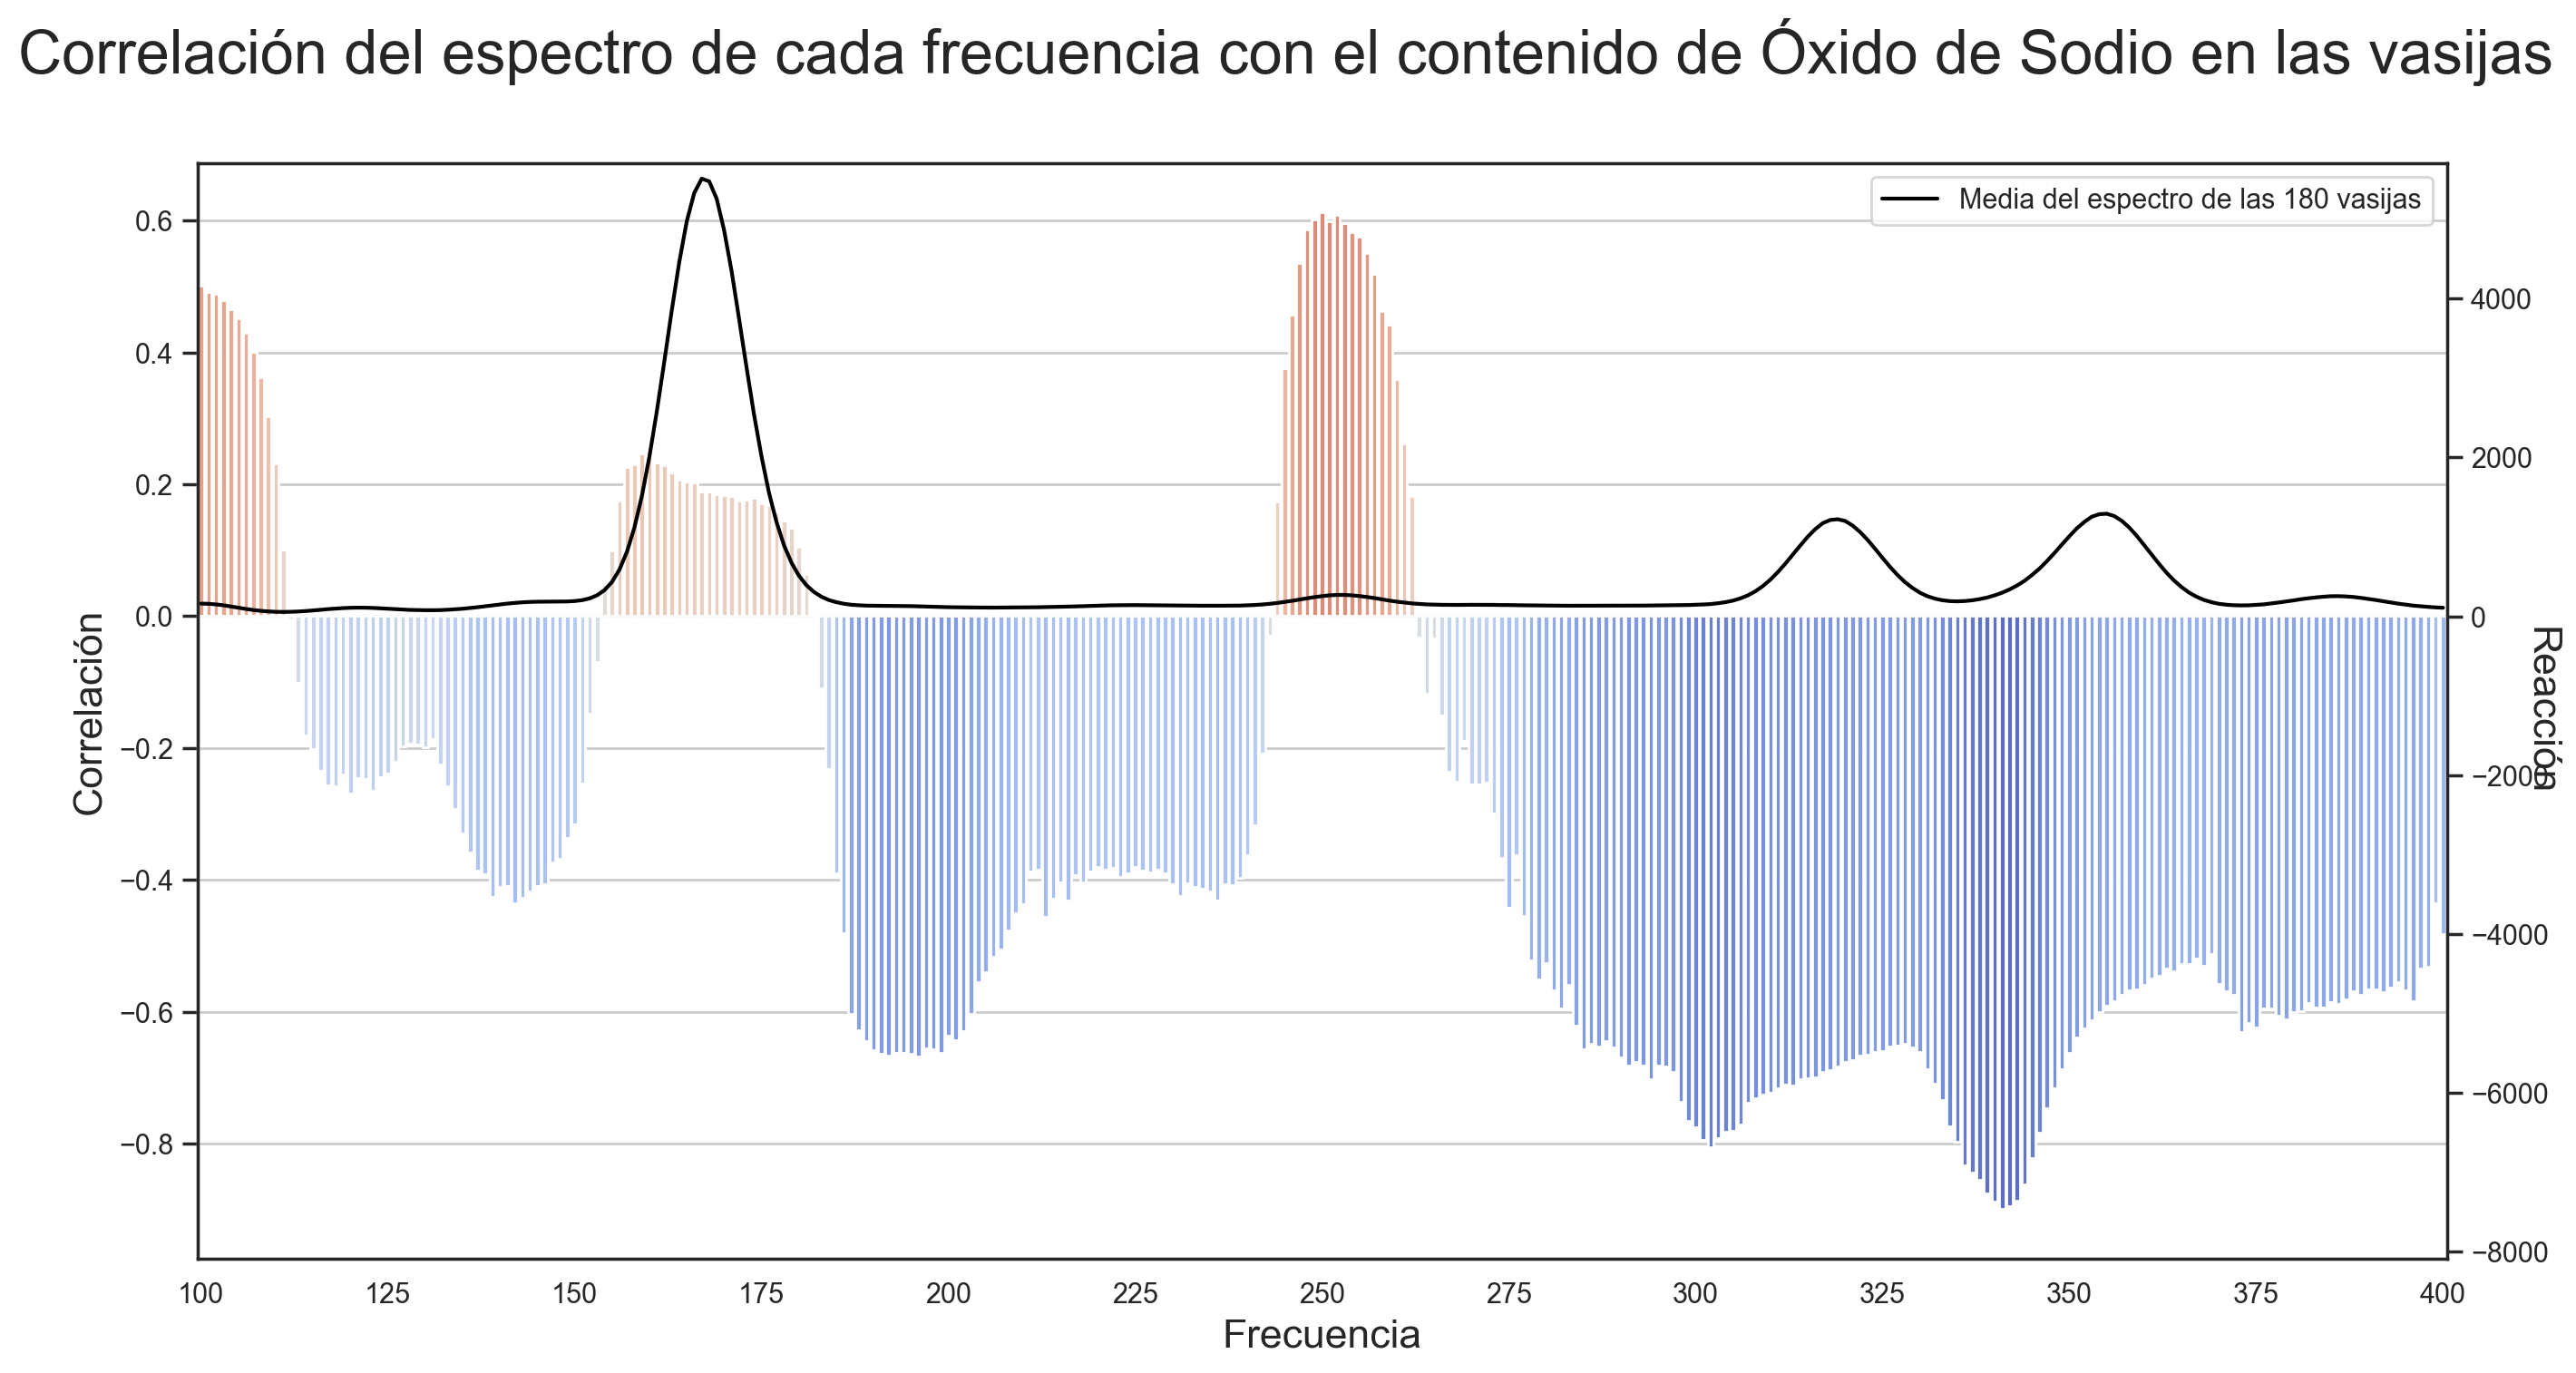

In [141]:
corrs = dfY.corr()['Y'].drop('Y')

sns.set_theme(style="whitegrid")

cmap = plt.cm.coolwarm
colores = [cmap(i) for i in range(cmap.N)]
coloresplot = [colores[int(128 + y*128)] for y in pd.Series(corrs)]


fig, ax = plt.subplots(nrows=1, ncols=1, dpi=200, figsize=(16, 8))
sns.set_theme(style="ticks", palette="flare")


ax.set_xlim(100, 400)

sns.barplot(x=list(range(100, 401)),
            y=pd.Series(corrs),
            palette=coloresplot,
            ax=ax)

ax2 = ax.twinx()
ax2.set_ylim(-1.416*(max(df.mean())+200), max(df.mean()) + 200)

sns.lineplot(x=list(range(0, 301)),
             y=df.mean(),
             ax=ax2,
             color='#000000',
             label="Media del espectro de las 180 vasijas")

ax.set_xticklabels([t if not i%25 else "" for i,t in enumerate(ax.get_xticklabels())])


plt.suptitle('Correlación del espectro de cada frecuencia con el contenido de Óxido de Sodio en las vasijas', fontsize=24)
ax.set_xlabel("Frecuencia", fontsize=16)
ax.set_ylabel("Correlación", fontsize=16)
ax2.set_ylabel("Reacción", fontsize=16, rotation=-90)
ax2.legend()
plt.plot()

[]

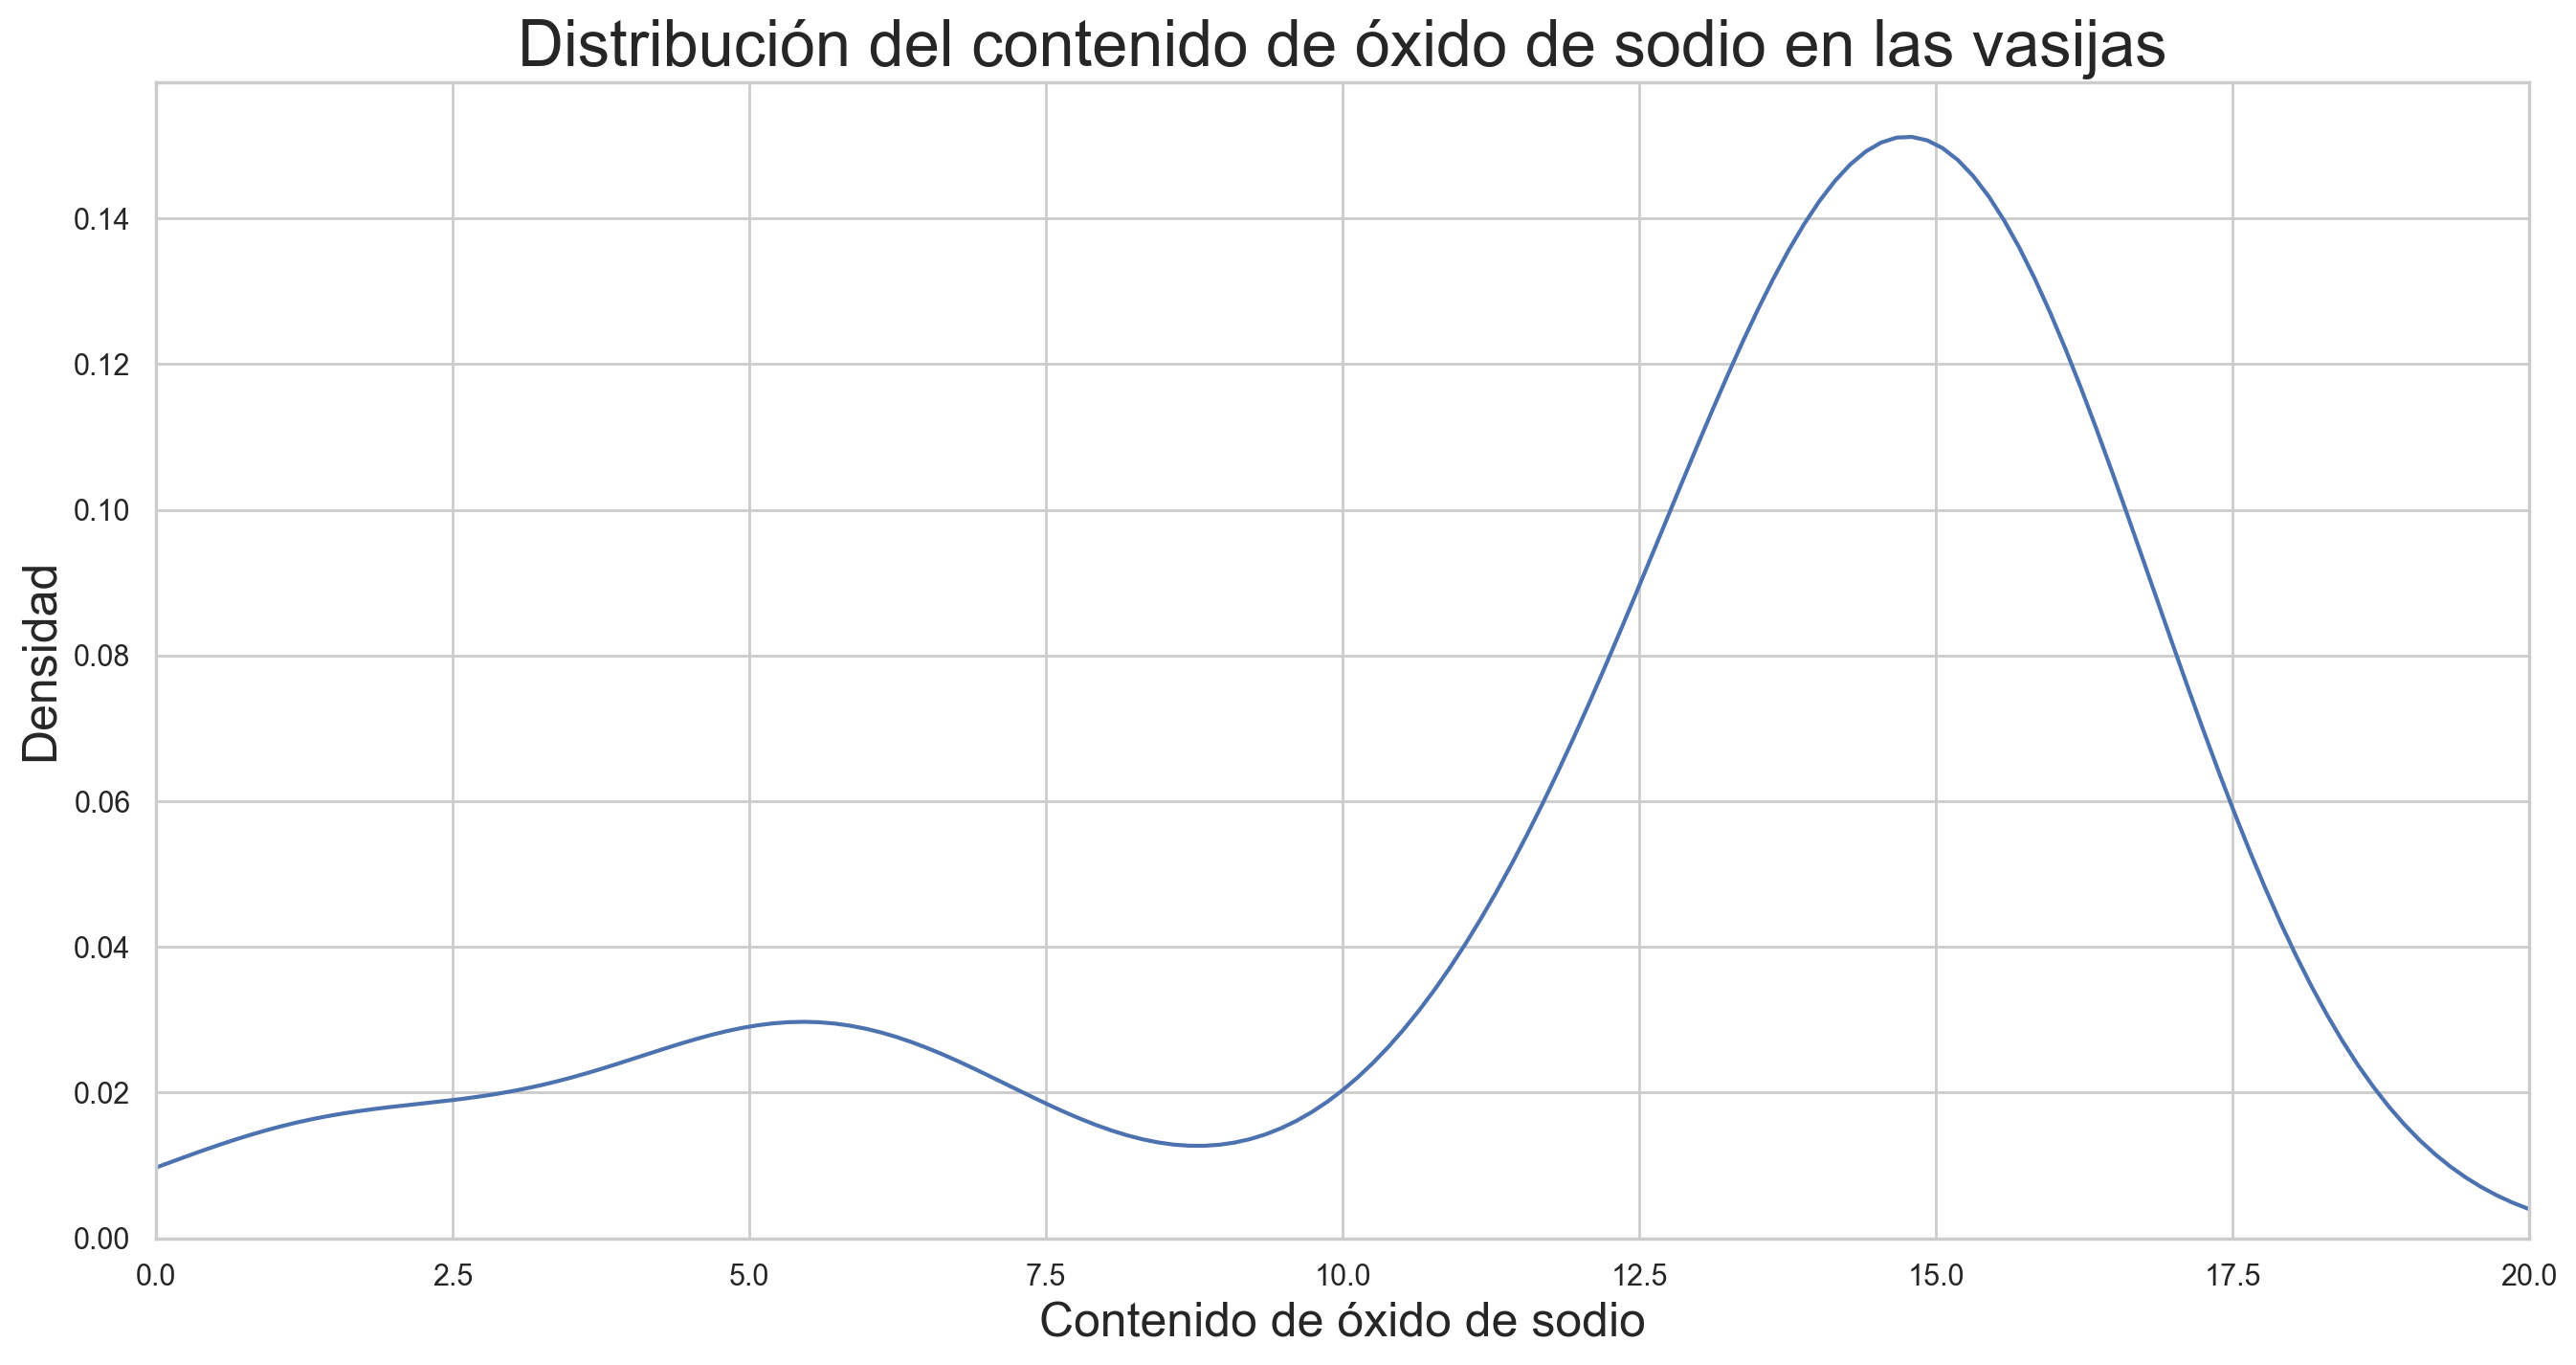

In [177]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(nrows=1, ncols=1, dpi=200, figsize=(16, 8))

plt.title('Distribución del contenido de óxido de sodio en las vasijas', fontsize=24)

sns.kdeplot(np.array(dfY['Y']), ax=ax)

ax.set_xlim(0, 20)
ax.set_ylabel("Densidad", fontsize=18)
ax.set_xlabel("Contenido de óxido de sodio", fontsize=18)

plt.plot()

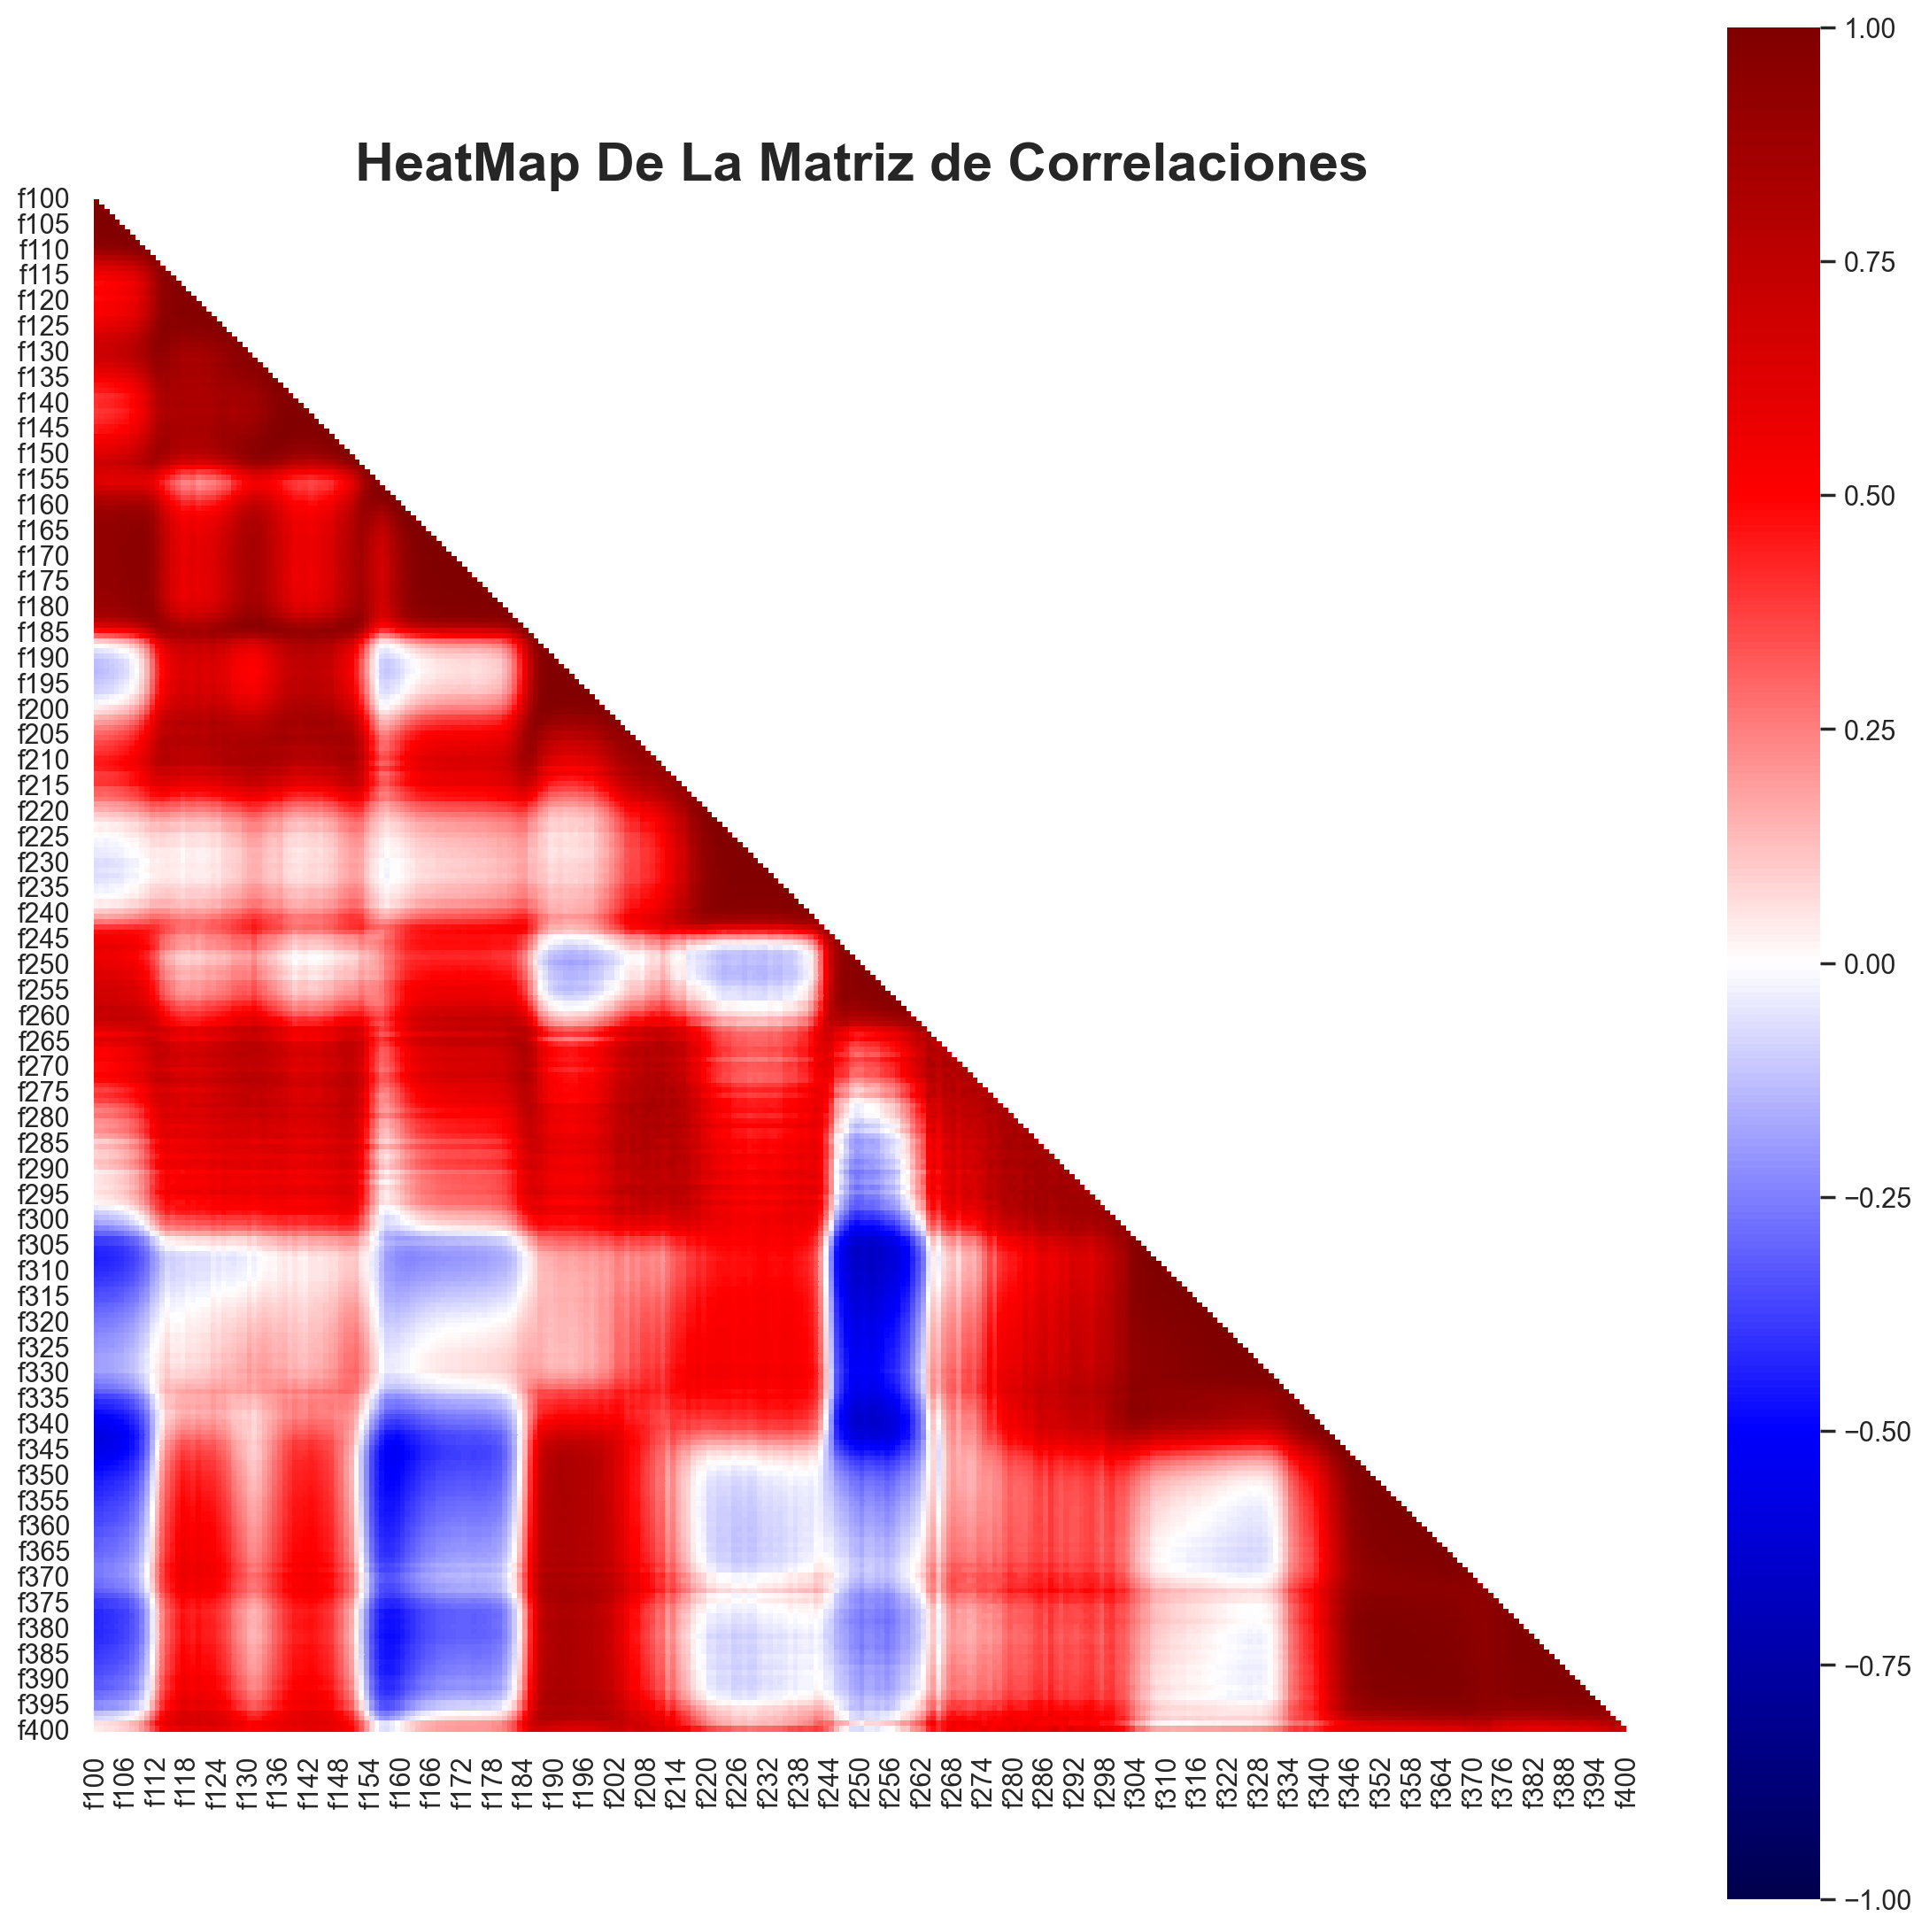

In [11]:

corrs = df.corr()

mask = np.zeros_like(corrs)
mask[np.triu_indices_from(mask)] = True    
with sns.axes_style("white"):
      f, ax = plt.subplots(dpi=200, figsize=(14, 14))
      ax = sns.heatmap(corrs, mask=mask, vmin=-1, vmax=1, square=True, cmap='seismic')
      ax.set_title("HeatMap De La Matriz de Correlaciones", weight='bold', size=22)
